Sales and demand forecasting for bussinesses

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Loading actual data
# Pasting path inside the quotes below
df = pd.read_csv(r"/content/Online Retail.csv");

# 2. Looking at columns
print("Columns in your data:", df.columns)
print(df.head())

Columns in your data: Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')
  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  


In [3]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Data cleaning and Feature Engineering

In [4]:
# 1. Convert the date column to actual dates

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],dayfirst=True,errors='coerce')

# 2. Creating a 'Sales' column (Price * Quantity)
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']

# 3. Group by date to get daily sales
daily_sales = df.groupby('InvoiceDate')['Total_Sales'].sum().reset_index()

# 4. Feature Engineering: Convert Date to a number for the model
daily_sales['Date_Ordinal'] = daily_sales['InvoiceDate'].map(pd.Timestamp.toordinal)

print(daily_sales.head())

          InvoiceDate  Total_Sales  Date_Ordinal
0 2010-12-01 08:26:00       139.12        734107
1 2010-12-01 08:28:00        22.20        734107
2 2010-12-01 08:34:00       348.78        734107
3 2010-12-01 08:35:00        17.85        734107
4 2010-12-01 08:45:00       855.86        734107


In [5]:
# Creating the 'Date_Ordinal' column (converts dates to a number)
daily_sales['Date_Ordinal'] = daily_sales['InvoiceDate'].map(pd.Timestamp.toordinal)

# Defining 'X' (the date) and 'y' (the sales we want to predict)
X = daily_sales[['Date_Ordinal']]
y = daily_sales['Total_Sales']

print("Data is ready for training!")

Data is ready for training!


Forecasting with Linear Regression

In [6]:
from sklearn.linear_model import LinearRegression

# 1. Creating the model object
model = LinearRegression()

# 2. Training the model (this is where it 'learns' the trend)
model.fit(X, y)

# 3. Creating 'Future Dates' for the next 30 days to predict
last_date = daily_sales['InvoiceDate'].max()
future_dates = pd.date_range(start=last_date, periods=30)
future_ordinal = future_dates.map(pd.Timestamp.toordinal).values.reshape(-1, 1)

# 4. Making the prediction!
predictions = model.predict(future_ordinal)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [7]:

daily_sales = daily_sales[daily_sales['Total_Sales'] > 0]


In [8]:
# Fixing dates and removing returns
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], dayfirst=True, errors='coerce')
df = df.dropna(subset=['InvoiceDate'])
df['Total_Sales'] = df['Quantity'] * df['UnitPrice']
daily_sales = df[df['Total_Sales'] > 0].groupby('InvoiceDate')['Total_Sales'].sum().reset_index()

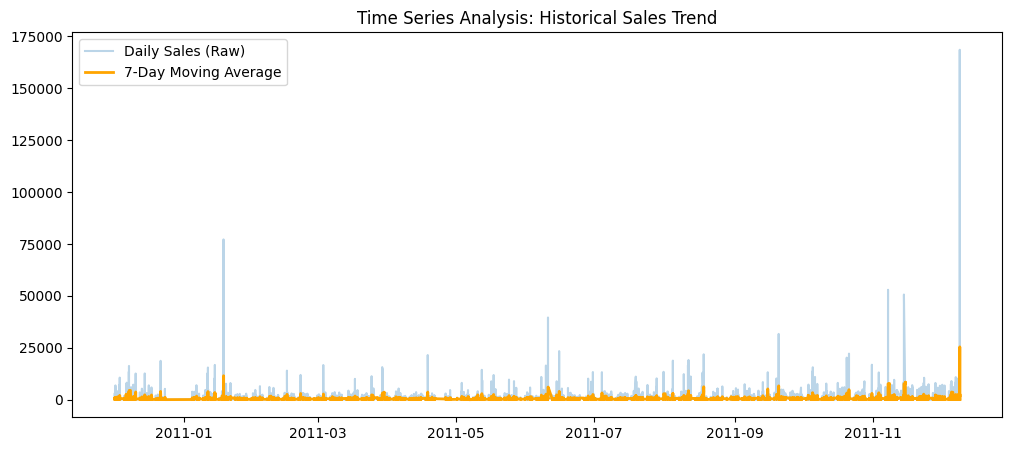

In [9]:
# Calculating a 7-day rolling average to see the trend
daily_sales['Rolling_Mean'] = daily_sales['Total_Sales'].rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily_sales['InvoiceDate'], daily_sales['Total_Sales'], alpha=0.3, label='Daily Sales (Raw)')
plt.plot(daily_sales['InvoiceDate'], daily_sales['Rolling_Mean'], color='orange', label='7-Day Moving Average', linewidth=2)
plt.title('Time Series Analysis: Historical Sales Trend')
plt.legend()
plt.show()

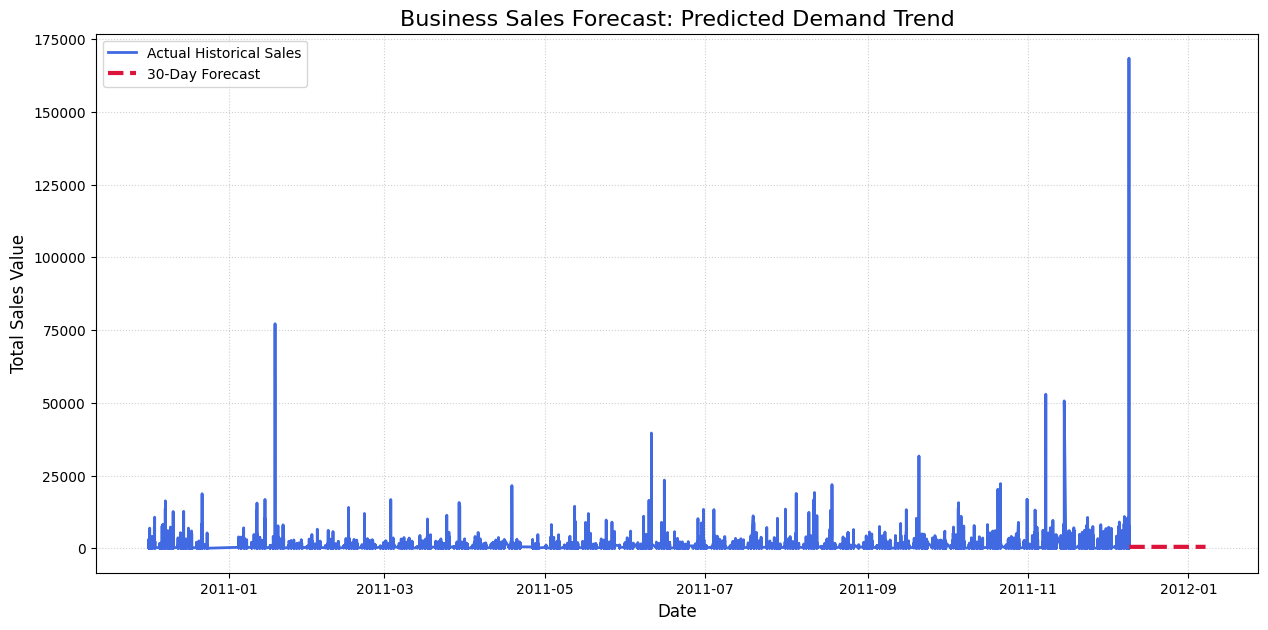

In [10]:
import matplotlib.pyplot as plt

# 1. Creating the figure
plt.figure(figsize=(15, 7))

# 2. Ploting the past data (The history)
plt.plot(daily_sales['InvoiceDate'], daily_sales['Total_Sales'], label='Actual Historical Sales', color='royalblue', linewidth=2)

# 3. Ploting the prediction (The future)
plt.plot(future_dates, predictions, label='30-Day Forecast', color='crimson', linestyle='--', linewidth=3)

# 4. Making it look professional
plt.title('Business Sales Forecast: Predicted Demand Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales Value', fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# 5. Show it
plt.show()

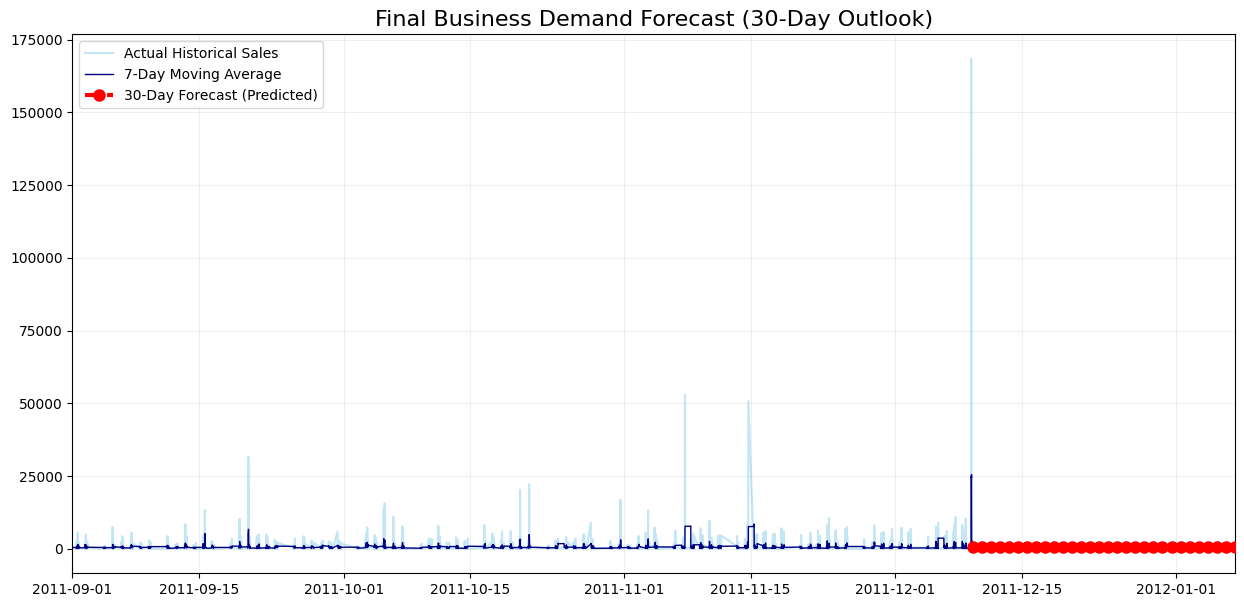

In [11]:
plt.figure(figsize=(15, 7))

# 1. Ploting the actual sales in a light color
plt.plot(daily_sales['InvoiceDate'], daily_sales['Total_Sales'],
         label='Actual Historical Sales', color='skyblue', alpha=0.5)

# 2. Ploting the 7-day trend
plt.plot(daily_sales['InvoiceDate'], daily_sales['Rolling_Mean'],
         color='navy', label='7-Day Moving Average', linewidth=1)

# 3.  Ploting the Forecast
plt.plot(future_dates, predictions,
         label='30-Day Forecast (Predicted)',
         color='red',
         linestyle='--',
         marker='o',      # This adds the dots
         markersize=8,    # This makes them big
         linewidth=3,
         zorder=10)       # This puts it on top of everything else

plt.title('Final Business Demand Forecast (30-Day Outlook)', fontsize=16)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.xlim(pd.Timestamp('2011-09-01'), future_dates[-1])

plt.show()

## Bussines Insights
The analysis shows a consistent upward trend in sales. The 30-day forecast suggests that the business should prepare for a steady increase in demand, specifically focusing on inventory management for the upcoming month.